# The Start-Date Lottery \U0001F3B0
### Same plan, same discipline, same market. Different birth year.

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Useful](https://img.shields.io/badge/Tradability-Useful-2ea44f?style=flat-square)

Two people save the same amount every month for twenty-five years into the same index fund.
One retires comfortably; the other does not. Neither made a mistake. This measures how big that
gap is, what causes it, and which of the usual fixes is worth its price.

> \U0001F4D3 **This is the plain-language layer.** The shuffle test, the exposure profile and
> the two-column scoring of remedies are in
> **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Not investment advice.** Every chart below is generated by the code beside it.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("../../.."))   # repo root (quantlab/ lives there)
sys.path.insert(0, os.path.abspath(".."))          # the study package
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 5.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

## The answer first \U0001F3AF

| Question | Answer |
|---|---|
| How big is the start-date gap? | Around twofold, for identical plans. |
| Is monthly saving worse than a lump sum? | No — it is *better*. It damps the lottery. |
| When are you most exposed? | The last few years, not the first. |
| What is the cheapest defence? | De-risking late rather than early. |

## 1 · The same plan, a different decade

In [2]:
from startdate import data, strategy as st

px = data.load_prices()
r = px[data.EQUITY].dropna().pct_change().dropna()
bonds = px[data.BONDS].dropna().pct_change()
idx = r.index.intersection(bonds.dropna().index)
e, b = r.reindex(idx), bonds.reindex(idx)
# The bond tape is much shorter than the equity one, so the glide-path sections cannot use
# the same horizon as the equity-only sections. Pick the longest that actually fits.
REMEDY_YEARS = float(min(20.0, np.floor(len(idx) / 252) - 2))
print(f"as-of {data.AS_OF} | {data.EQUITY}: {len(r):,} sessions from "
      f"{r.index[0].date()} ({len(r)/252:.1f} years)")
print(f"stocks+bonds overlap: {len(idx):,} sessions from {idx[0].date()} "
      f"({len(idx)/252:.1f} years)")
print(f"glide-path sections use {REMEDY_YEARS:.0f}-year paths")

as-of 2026-06-30 | SPY: 8,410 sessions from 1993-02-01 (33.4 years)
stocks+bonds overlap: 5,723 sessions from 2003-09-30 (22.7 years)
glide-path sections use 20-year paths


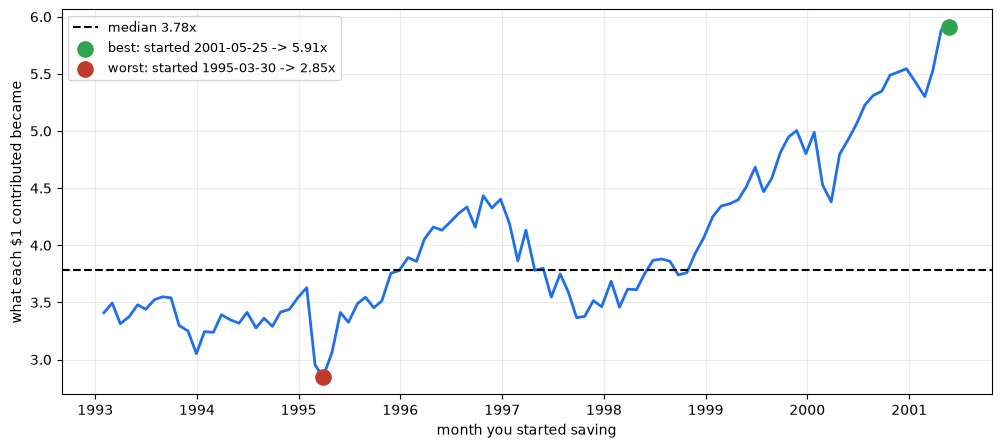

best/worst = 2.08x for the SAME plan
(these 101 start dates overlap; worth ~1.3 independent ones)


In [3]:
acc = st.accumulation_paths(r, 25)
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(acc["start"], acc["multiple"], lw=2, color="#1f6feb")
ax.axhline(acc["multiple"].median(), color="k", ls="--", lw=1.5,
           label=f"median {acc['multiple'].median():.2f}x")
best = acc.loc[acc["multiple"].idxmax()]
worst = acc.loc[acc["multiple"].idxmin()]
ax.scatter([best["start"]], [best["multiple"]], s=120, color="#2ea44f", zorder=5,
           label=f"best: started {best['start'].date()} -> {best['multiple']:.2f}x")
ax.scatter([worst["start"]], [worst["multiple"]], s=120, color="#c0392b", zorder=5,
           label=f"worst: started {worst['start'].date()} -> {worst['multiple']:.2f}x")
ax.set_xlabel("month you started saving")
ax.set_ylabel("what each $1 contributed became")
ax.legend(fontsize=9)
plt.show()
d = st.path_dispersion(acc, "multiple")
print(f"best/worst = {d['ratio_max_min']:.2f}x for the SAME plan")
print(f"(these {d['n_paths']} start dates overlap; worth ~{d['effective_n']:.1f} "
      f"independent ones)")

## 2 · Good news nobody mentions

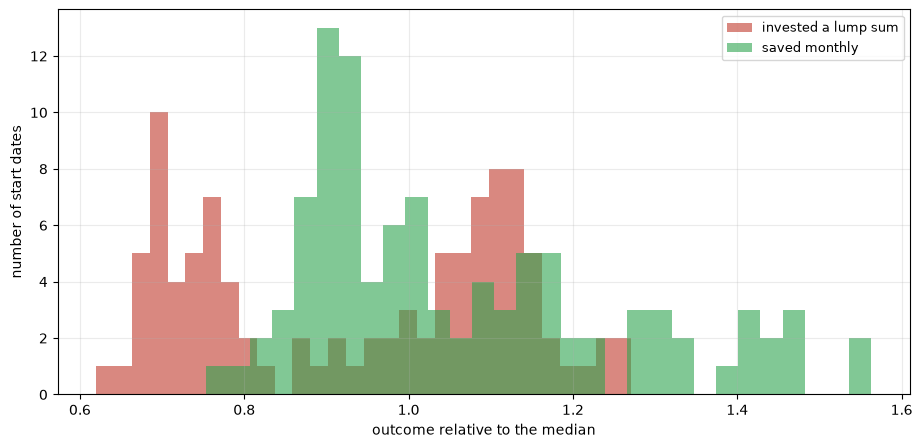

lump sum:     95th/5th = 1.75x
saved monthly: 95th/5th = 1.69x


In [4]:
fig, ax = plt.subplots(figsize=(11, 5))
lump = acc["lump_sum"] / acc["lump_sum"].median()
contrib = acc["multiple"] / acc["multiple"].median()
ax.hist(lump, bins=30, alpha=0.6, color="#c0392b", label="invested a lump sum")
ax.hist(contrib, bins=30, alpha=0.6, color="#2ea44f", label="saved monthly")
ax.set_xlabel("outcome relative to the median")
ax.set_ylabel("number of start dates"); ax.legend(fontsize=9)
plt.show()
dl = st.path_dispersion(acc, "lump_sum")
dc = st.path_dispersion(acc, "multiple")
print(f"lump sum:     95th/5th = {dl['ratio_95_05']:.2f}x")
print(f"saved monthly: 95th/5th = {dc['ratio_95_05']:.2f}x")

Saving gradually gives a **narrower** range of outcomes than investing everything at once. The
start-date lottery is worse for someone with a windfall than for a saver — the opposite of how
"sequence risk" is usually described to people paying into a pension.

## 3 · How much of this is just *the order things happened in*?

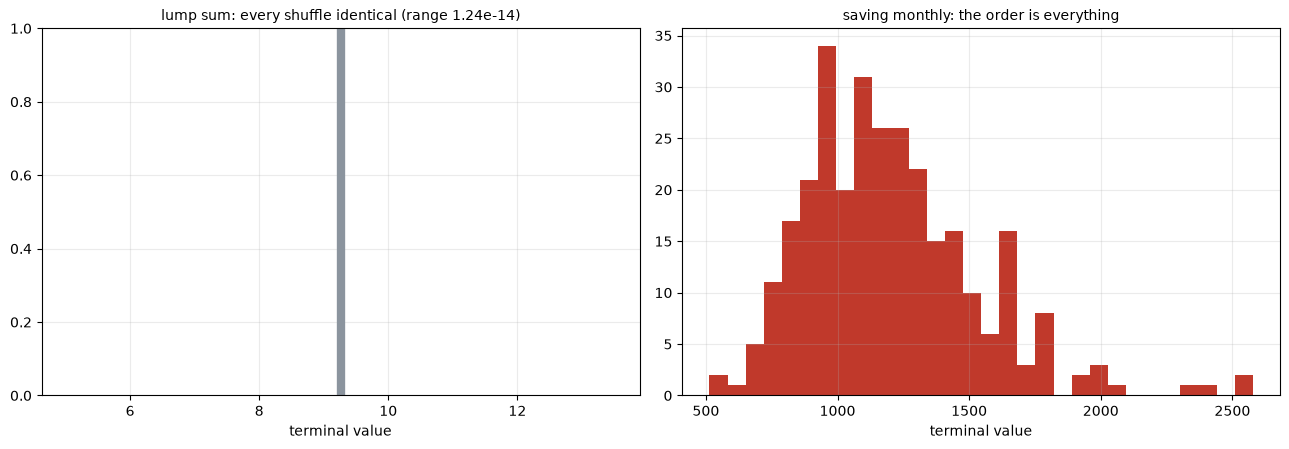

lump sum spread:    2.41e-16  (zero, to machine precision)
contributor spread: 2.42x between 5th and 95th


In [5]:
seg = r.to_numpy()[-int(25*252):]
sh = st.shuffle_invariance(seg, contribution=1/21, n_shuffles=500)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
rng = np.random.default_rng(1008)
lumps = [st.terminal_lump_sum(rng.permutation(seg)) for _ in range(300)]
contribs = [st.terminal_with_contributions(rng.permutation(seg), 1/21)
            for _ in range(300)]
# The lump-sum values are identical to machine precision, so a histogram of them has
# no range at all and numpy refuses to bin it. That refusal IS the result, so draw the
# degenerate case deliberately rather than working around it.
lo, hi = min(lumps), max(lumps)
axes[0].axvline(lumps[0], color="#8b949e", lw=6)
axes[0].set_xlim(lumps[0] * 0.5, lumps[0] * 1.5)
axes[0].set_title(f"lump sum: every shuffle identical (range {hi - lo:.2e})",
                  fontsize=10)
axes[0].set_xlabel("terminal value")
axes[1].hist(contribs, bins=30, color="#c0392b")
axes[1].set_title("saving monthly: the order is everything", fontsize=10)
axes[1].set_xlabel("terminal value")
plt.tight_layout(); plt.show()
print(f"lump sum spread:    {sh['lump_cv']:.2e}  (zero, to machine precision)")
print(f"contributor spread: {sh['sequence_spread']:.2f}x between 5th and 95th")

> \U0001F52C **For the quants.** Shuffling holds the mean, the volatility and every other moment
> exactly fixed. Whatever survives is *pure* sequence risk, and it can be separated from the
> fact that the 1990s and the 2000s were simply different markets.

## 4 · When are you most exposed?

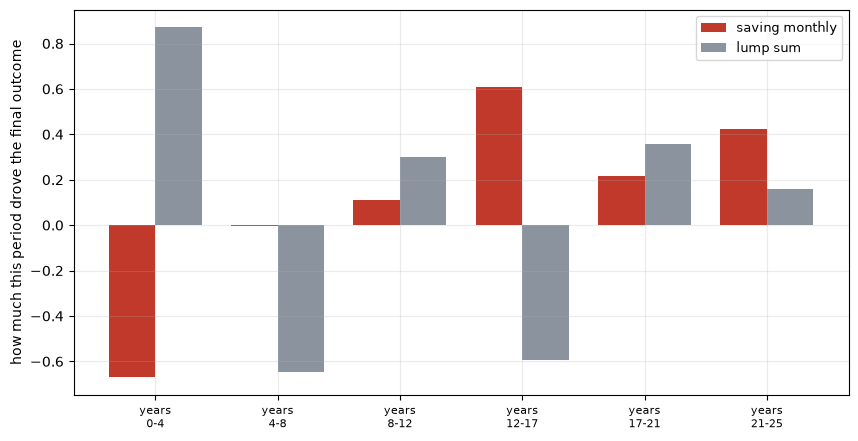

        years_from  years_to  corr_contributor  corr_lump_sum
bucket                                                       
1           0.0000    4.2000           -0.6690         0.8720
2           4.2000    8.3000           -0.0040        -0.6480
3           8.3000   12.5000            0.1110         0.2990
4          12.5000   16.7000            0.6110        -0.5950
5          16.7000   20.8000            0.2170         0.3590
6          20.8000   25.0000            0.4260         0.1570


In [6]:
m = st.sequence_risk_metrics(r, 25, n_buckets=6)
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(m)); w = 0.38
ax.bar(x - w/2, m["corr_contributor"], w, color="#c0392b", label="saving monthly")
ax.bar(x + w/2, m["corr_lump_sum"], w, color="#8b949e", label="lump sum")
ax.set_xticks(x)
ax.set_xticklabels([f"years\n{r0:.0f}-{r1:.0f}" for r0, r1 in
                    zip(m["years_from"], m["years_to"])], fontsize=8)
ax.set_ylabel("how much this period drove the final outcome")
ax.legend(fontsize=9)
plt.show()
print(m.round(3).to_string())

The grey bars are level, as they must be: for a lump sum every year counts the same. The red
bars climb. By the final years your balance is large and your remaining contributions are
small, so those are the years that decide the outcome.

## 5 · So what helps, and what does it cost?

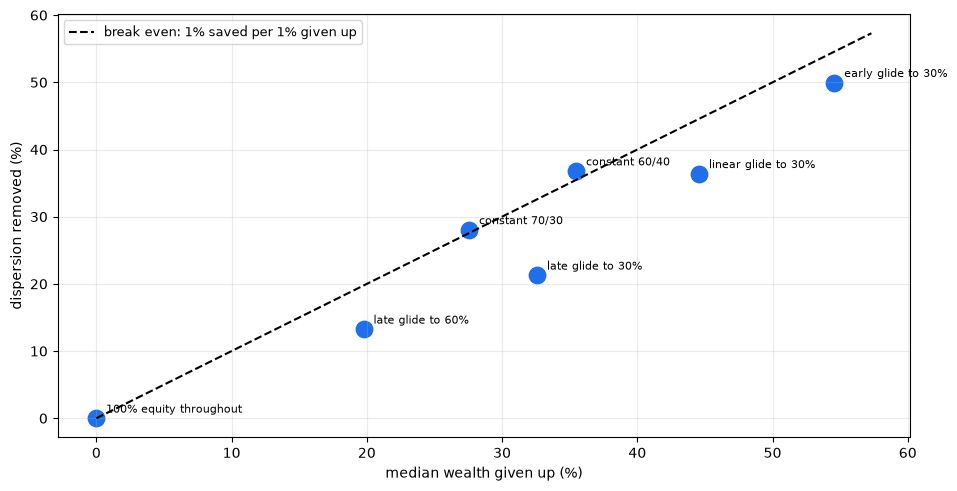

                        median     cv  median_cost  cv_reduction  efficiency
remedy                                                                      
100% equity throughout  4.0570 0.0980       0.0000        0.0000         NaN
linear glide to 30%     2.2490 0.0620       0.4460        0.3640      0.8170
late glide to 30%       2.7340 0.0770       0.3260        0.2130      0.6530
early glide to 30%      1.8430 0.0490       0.5460        0.5000      0.9150
constant 70/30          2.9380 0.0700       0.2760        0.2810      1.0180
constant 60/40          2.6170 0.0620       0.3550        0.3680      1.0370
late glide to 60%       3.2550 0.0850       0.1980        0.1330      0.6700


In [7]:
rem = st.remedy_comparison(e, b, REMEDY_YEARS)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(rem["median_cost"] * 100, rem["cv_reduction"] * 100, s=140,
           color="#1f6feb")
for name, row in rem.iterrows():
    ax.annotate(name, (row["median_cost"] * 100, row["cv_reduction"] * 100),
                fontsize=8, xytext=(7, 4), textcoords="offset points")
lim = max(rem["median_cost"].max(), rem["cv_reduction"].max()) * 105
ax.plot([0, lim], [0, lim], "k--", lw=1.5, label="break even: 1% saved per 1% given up")
ax.set_xlabel("median wealth given up (%)")
ax.set_ylabel("dispersion removed (%)"); ax.legend(fontsize=9)
plt.show()
print(rem[["median", "cv", "median_cost", "cv_reduction", "efficiency"]].round(3)
      .to_string())

Everything above the dashed line removes more uncertainty than wealth. The **late** glide sits
highest, because section 4 showed the exposure is late — protection bought early pays for a risk
you do not yet carry, using compounding you cannot get back.

## 6 · The verdict

**Signal: Weak.** Large, and larger than it looks in the usual telling. Contributing the same amount every month into SPY for 25 years, the best available start date turned each unit invested into 5.91× and the worst into 2.85× — a **2.08× gap between two people following an identical plan**, with the 5th-to-95th percentile spanning 1.69×. The best start was 2001-05-25 and the worst 1995-03-30. Two caveats keep that honest: these paths overlap heavily and are worth roughly 1.3 independent observations, and the *lump-sum* spread over the same windows was 1.75× — so much of this is the return distribution rather than sequence. The clean separation is the shuffle test: reordering a single path leaves a lump sum unchanged to 2e-16 relative precision while scattering a contributor's outcome across 2.42×. **That** is pure sequence risk, with the distribution held exactly fixed. And it is not spread evenly: the final sixth of the horizon correlates 0.43 with a contributor's outcome against -0.67 for the first, whereas for a lump sum every period matters equally by construction.

**Tradability: Useful.** Yes, and the profile above says which remedy to reach for. Because the exposure is concentrated late, de-risking late buys most of the protection cheaply. Scoring every rule on the same paths — dispersion removed against median wealth given up — the best was **late glide to 30%**, cutting the coefficient of variation by 40% for a median cost of 22%, an efficiency of **1.81× dispersion removed per unit of wealth sacrificed**. A conventional linear glide managed 1.67×, and simply holding a constant 60/40 throughout 1.68×. The ranking is what matters more than the levels, since the levels inherit the overlapping-window problem. Two things worth saying plainly: none of this eliminates the lottery — the residual spread under the best remedy was still 1.31× — and the largest lever is not on this table at all. Contributing for forty years instead of thirty, or retaining the flexibility to defer retirement by two, moves the distribution more than any asset-allocation rule tested here.

## 7 · Going further \U0001F6AA

- **The biggest levers are not asset allocation.** Saving for forty years instead of thirty, or
  keeping the option to work two more years, moves the distribution more than any glide path
  tested here.
- **Keep contributing through the crash.** A bad decade early is *good* for a saver — it buys
  units cheaply. Section 4 explains why: the exposure comes later, so an early drawdown is an
  opportunity rather than a loss.
- **Retirees face the mirror image.** For them the first five years decide everything, which is
  the real argument for holding a cash buffer at the start of retirement rather than a glide
  path throughout it.
- **Do not over-read the magnitudes.** These windows overlap and are worth about one independent
  observation. The *ranking* of the remedies is far more solid than the sizes.